Downloading and stuff

In [ ]:
!pip install -q openml

import openml
import pandas as pd

# Fetch Ames Housing dataset
dataset = openml.datasets.get_dataset(42165)  # Ames Housing

X, y, categorical, feature_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format="dataframe"
)

df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000


In [ ]:
print("Target column:", dataset.default_target_attribute)
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False).head(10))

Target column: SalePrice

Missing values:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageFinish      81
GarageQual        81
GarageYrBlt       81
GarageType        81
dtype: int64


In [ ]:
# Copy dataset
data = df.copy()

TARGET = dataset.default_target_attribute  # SalePrice

# Separate features
X = data.drop(columns=[TARGET])
y = data[TARGET]

# Identify feature types
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:", len(num_cols))
print("Categorical features:", len(cat_cols))


Numerical features: 24
Categorical features: 43


In [ ]:
# Fill numerical with median (safe baseline)
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical with "Missing"
for col in cat_cols:
    X[col] = X[col].fillna("Missing")

print("Remaining missing:", X.isnull().sum().sum())

Remaining missing: 0


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Create bins
y_binned = pd.qcut(y, q=10, labels=False, duplicates='drop')

# Train (70%) + temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y_binned,
    random_state=42
)

# Re-bin temp for second split
y_temp_binned = pd.qcut(y_temp, q=10, labels=False, duplicates='drop')

# Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp_binned,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (1022, 80)
Val: (219, 80)
Test: (219, 80)


In [ ]:
X_train.to_csv("X_train.csv", index=False)
y_train.to_csv("y_train.csv", index=False)

X_val.to_csv("X_val.csv", index=False)
y_val.to_csv("y_val.csv", index=False)

X_test.to_csv("X_test.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("All splits saved ✅")

All splits saved ✅


Exploratory Data Analysis (EDA) for Regression

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


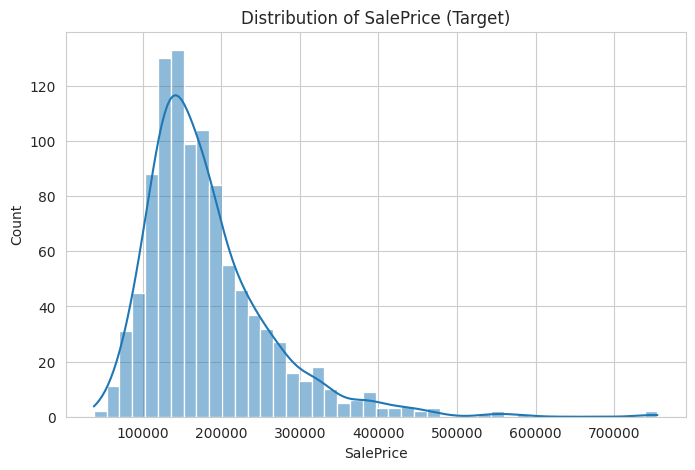

Skewness: 1.9652779779904928


In [ ]:
# Histogram + KDE
sns.histplot(y_train, kde=True)
plt.title("Distribution of SalePrice (Target)")
plt.show()

# Skewness
print("Skewness:", y_train.skew())

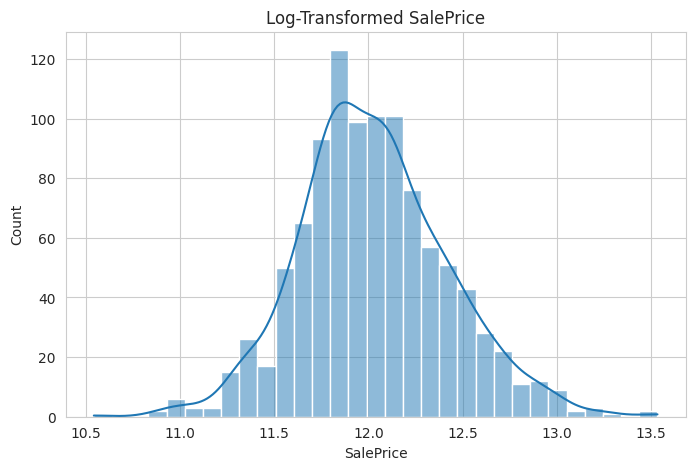

Skewness after log: 0.25481161893526844


In [ ]:
import numpy as np

y_train_log = np.log1p(y_train)

sns.histplot(y_train_log, kde=True)
plt.title("Log-Transformed SalePrice")
plt.show()

print("Skewness after log:", y_train_log.skew())

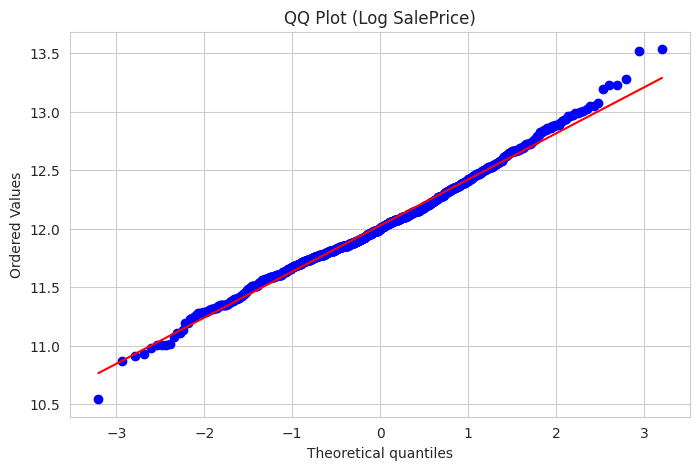

In [ ]:
stats.probplot(y_train_log, dist="norm", plot=plt)
plt.title("QQ Plot (Log SalePrice)")
plt.show()

In [ ]:
# Standardize before KS test
y_std = (y_train_log - y_train_log.mean()) / y_train_log.std()

ks_stat, p_value = stats.kstest(y_std, 'norm')

print("KS Statistic:", ks_stat)
print("p-value:", p_value)

KS Statistic: 0.043563902682742905
p-value: 0.0401215578922306


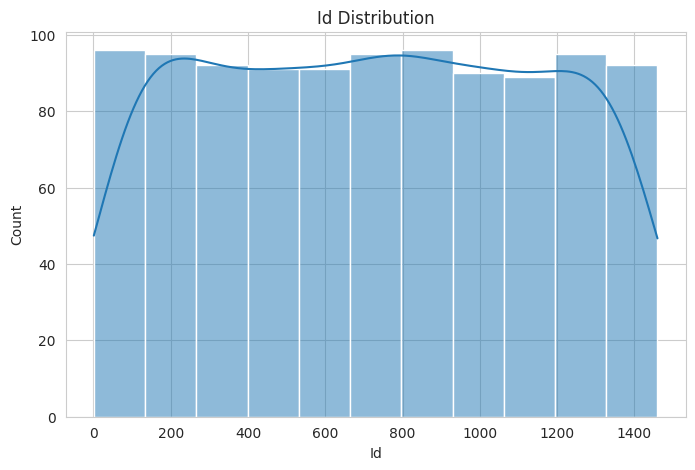

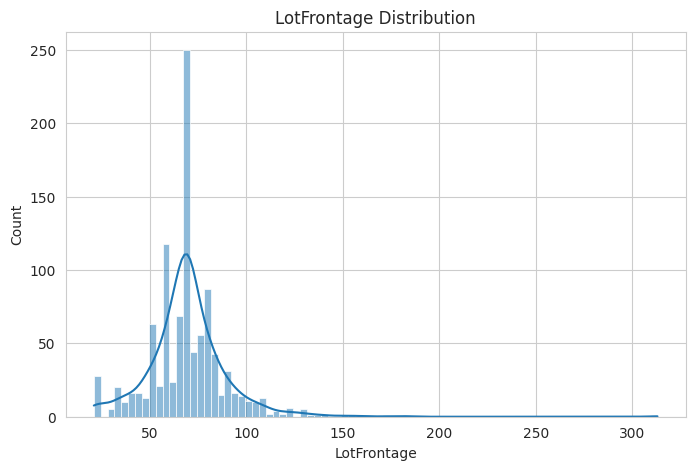

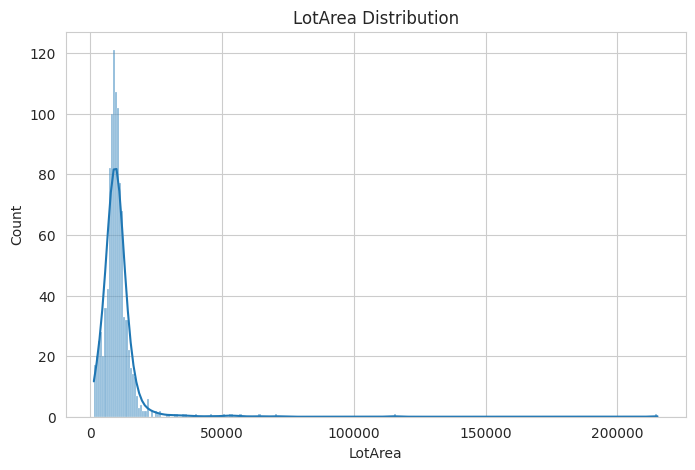

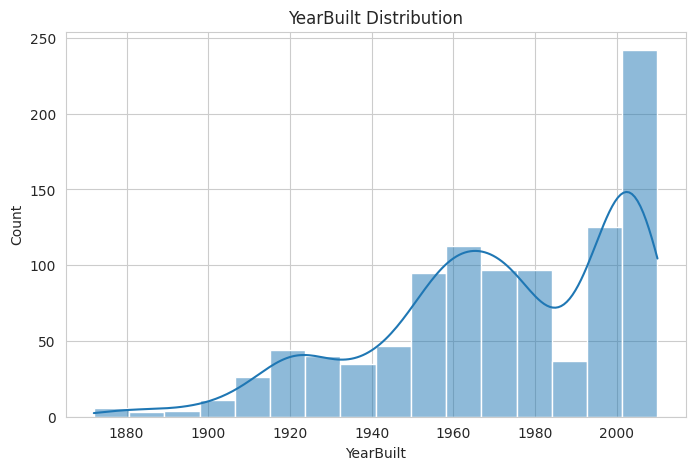

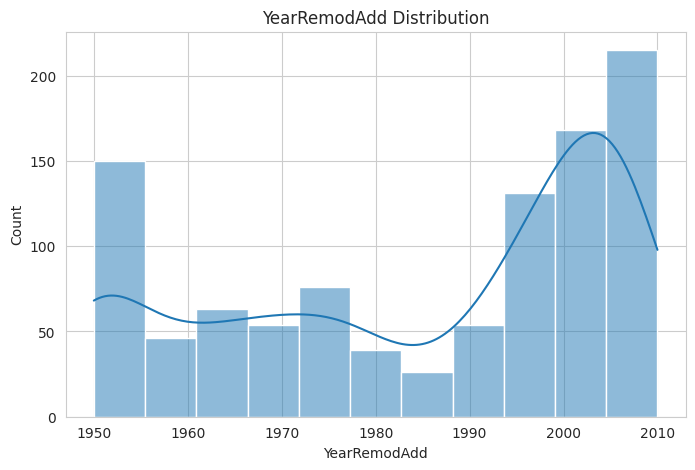

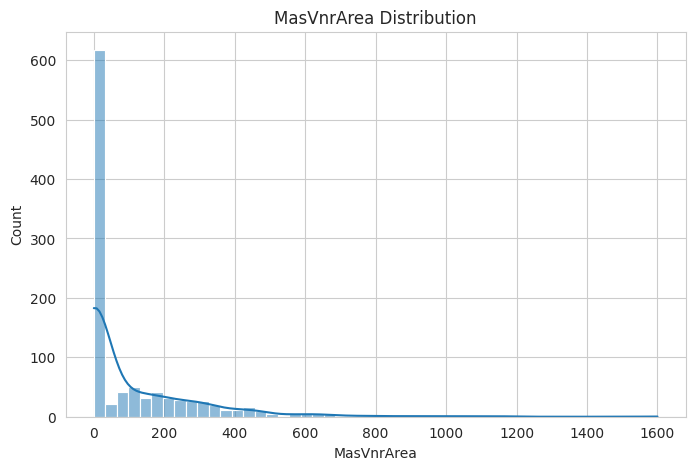

In [ ]:
# Select few important features
sample_cols = num_cols[:6]

for col in sample_cols:
    sns.histplot(X_train[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [ ]:
corr = X_train[num_cols].corrwith(y_train).sort_values(ascending=False)

print("Top positive correlations:\n", corr.head(10))
print("\nTop negative correlations:\n", corr.tail(10))

Top positive correlations:
 GrLivArea       0.699137
TotalBsmtSF     0.611091
GarageArea      0.609299
1stFlrSF        0.602329
YearBuilt       0.519617
YearRemodAdd    0.503846
GarageYrBlt     0.470140
MasVnrArea      0.428538
BsmtFinSF1      0.400732
WoodDeckSF      0.341671
dtype: float64

Top negative correlations:
 BsmtUnfSF        0.205144
ScreenPorch      0.139924
PoolArea         0.105819
3SsnPorch        0.055762
BsmtFinSF2      -0.002590
MiscVal         -0.013756
Id              -0.014519
YrSold          -0.015359
LowQualFinSF    -0.016881
EnclosedPorch   -0.121281
dtype: float64


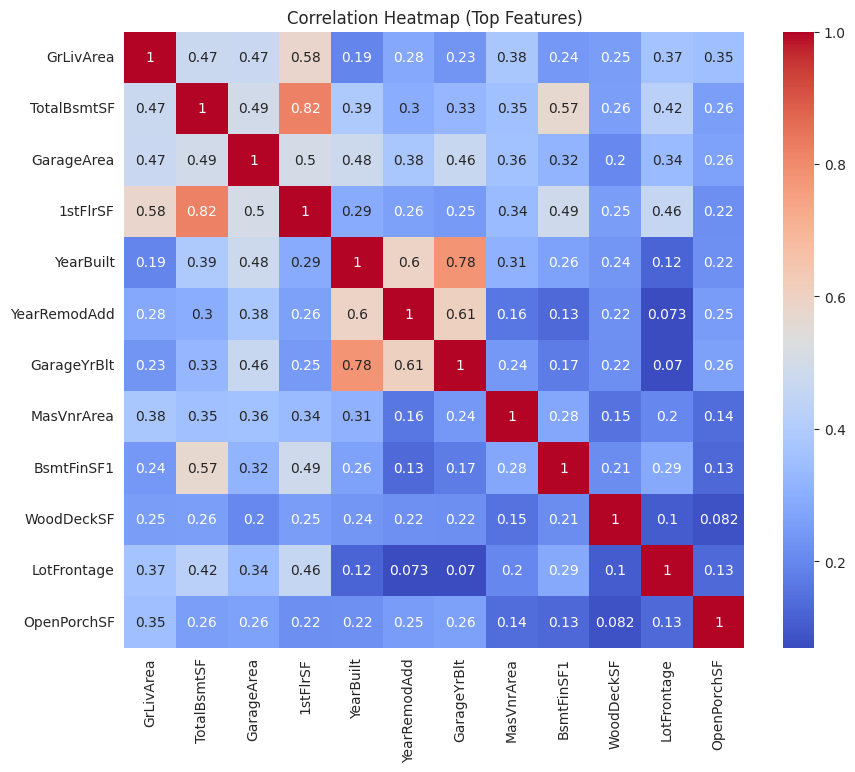

In [ ]:
top_features = corr.abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10,8))
sns.heatmap(X_train[top_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Top Features)")
plt.show()

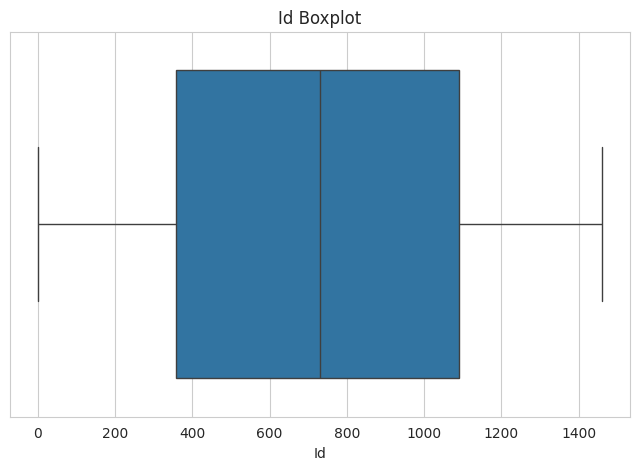

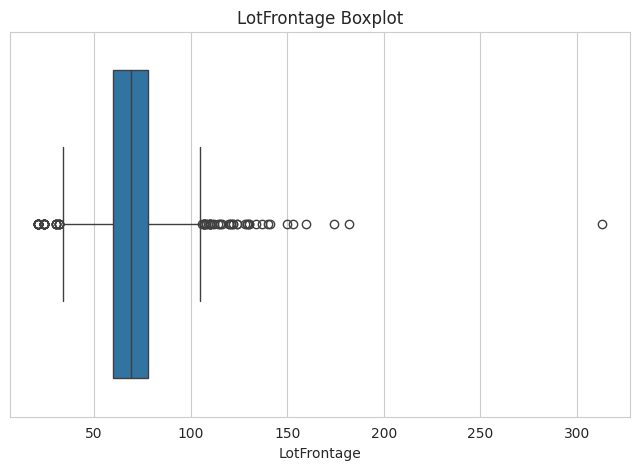

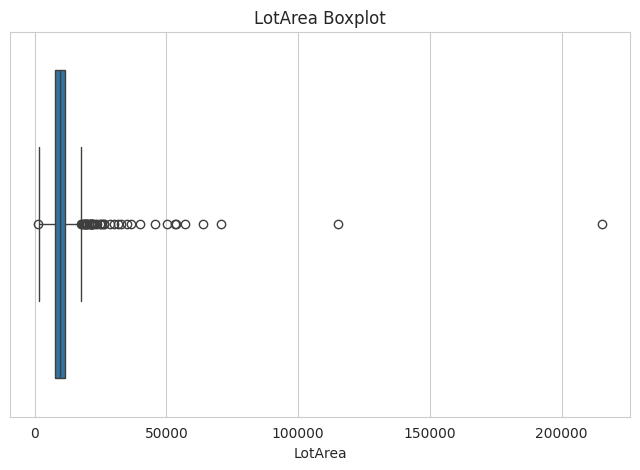

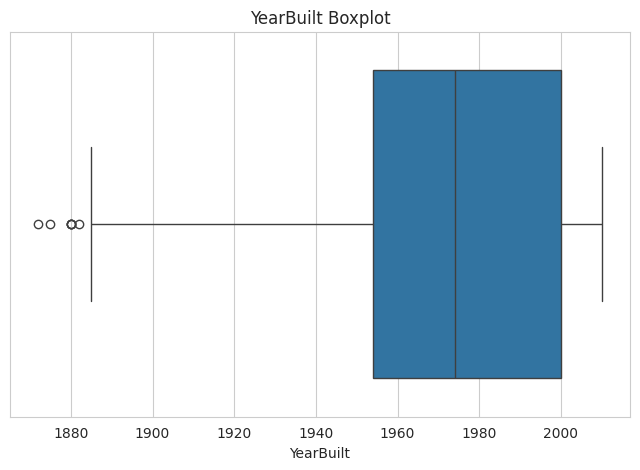

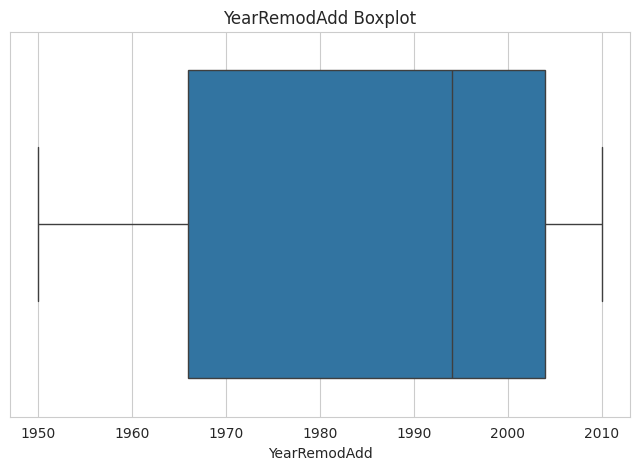

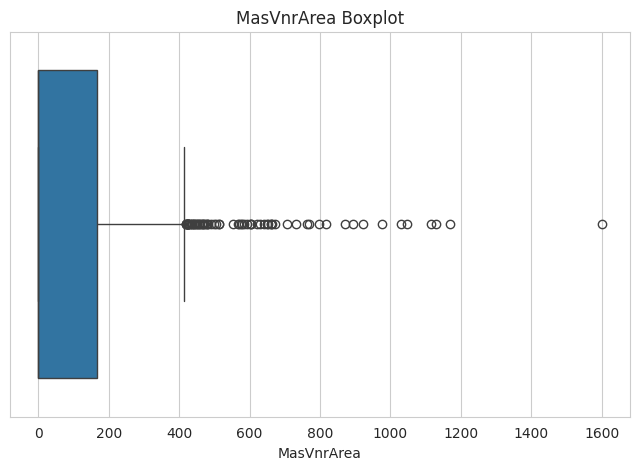

In [ ]:
for col in sample_cols:
    sns.boxplot(x=X_train[col])
    plt.title(f"{col} Boxplot")
    plt.show()

In [ ]:
from scipy.stats import kstest

for col in num_cols[:10]:  # sample to avoid overload
    data = X_train[col].dropna()
    data_std = (data - data.mean()) / data.std()

    stat, p = kstest(data_std, 'norm')
    print(f"{col}: p-value = {p:.4f}")

Id: p-value = 0.0007
LotFrontage: p-value = 0.0000
LotArea: p-value = 0.0000
YearBuilt: p-value = 0.0000
YearRemodAdd: p-value = 0.0000
MasVnrArea: p-value = 0.0000
BsmtFinSF1: p-value = 0.0000
BsmtFinSF2: p-value = 0.0000
BsmtUnfSF: p-value = 0.0000
TotalBsmtSF: p-value = 0.0000


SECTION 3: Feature Engineering + Multicollinearity (VIF)

In [ ]:
# Combine for consistency
X_all = pd.concat([X_train, X_val, X_test], axis=0)

# One-hot encode
X_all_enc = pd.get_dummies(X_all, drop_first=True)

# Split back
X_train_enc = X_all_enc.iloc[:len(X_train)].copy()
X_val_enc   = X_all_enc.iloc[len(X_train):len(X_train)+len(X_val)].copy()
X_test_enc  = X_all_enc.iloc[len(X_train)+len(X_val):].copy()

print("Encoded shape:", X_train_enc.shape)

Encoded shape: (1022, 262)


In [ ]:
# Basement components → keep TotalBsmtSF
X_train_enc = X_train_enc.drop(columns=[
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF"
], errors='ignore')

# Floor components → keep GrLivArea
X_train_enc = X_train_enc.drop(columns=[
    "1stFlrSF", "2ndFlrSF"
], errors='ignore')

print("After structural fix:", X_train_enc.shape)

After structural fix: (1022, 257)


In [ ]:
# Remove unstable categorical group
X_train_enc = X_train_enc.drop(
    columns=[col for col in X_train_enc.columns if "Condition2_" in col],
    errors='ignore'
)

# Remove rare feature group
X_train_enc = X_train_enc.drop(
    columns=[col for col in X_train_enc.columns if "MiscFeature_" in col],
    errors='ignore'
)

In [ ]:
threshold = 0.99

low_var_cols = [
    col for col in X_train_enc.columns
    if X_train_enc[col].value_counts(normalize=True).iloc[0] > threshold
]

print("Dropping low variance:", len(low_var_cols))

X_train_enc = X_train_enc.drop(columns=low_var_cols)

Dropping low variance: 68


In [ ]:
# Basement features
X_train_enc = X_train_enc.drop(columns=[
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF"
], errors='ignore')

# Floor features
X_train_enc = X_train_enc.drop(columns=[
    "1stFlrSF", "2ndFlrSF"
], errors='ignore')

# Now keep:
# TotalBsmtSF, GrLivArea

print("Shape after structural fix:", X_train_enc.shape)

Shape after structural fix: (1022, 243)


In [ ]:
import pandas as pd
import numpy as np

# Force numeric
X_vif = X_train_enc.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

vif_data = vif_data[vif_data["feature"] != "const"]

vif_data.sort_values(by="VIF", ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
160,GarageFinish_Missing,inf
114,BsmtQual_Missing,inf
117,BsmtCond_Missing,inf
126,BsmtFinType1_Missing,inf
132,BsmtFinType2_Missing,inf
159,GarageType_Missing,inf
164,GarageQual_Missing,inf
167,GarageCond_Missing,inf
89,Exterior1st_VinylSd,58.456575
34,MSZoning_RL,51.146789


In [ ]:
def reduce_vif(X, thresh=10):
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    X = X.copy().apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

    while True:
        X_const = sm.add_constant(X)

        vif = pd.Series(
            [variance_inflation_factor(X_const.values, i)
             for i in range(X_const.shape[1])],
            index=X_const.columns
        )

        vif = vif.drop("const")
        max_vif = vif.max()

        if max_vif > thresh:
            drop_col = vif.idxmax()
            print(f"Dropping {drop_col} (VIF={max_vif:.2f})")
            X = X.drop(columns=[drop_col])
        else:
            break

    return X

X_train_vif = reduce_vif(X_train_enc, thresh=10)

print("Final shape:", X_train_vif.shape)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping BsmtQual_Missing (VIF=inf)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping BsmtCond_Missing (VIF=inf)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


...

Dropping GarageType_Missing (VIF=inf)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping GarageFinish_Missing (VIF=inf)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping GarageQual_Missing (VIF=inf)
Dropping Exterior1st_VinylSd (VIF=58.46)
Dropping MSZoning_RL (VIF=51.09)
Dropping GarageType_Attchd (VIF=46.82)
Dropping SaleCondition_Partial (VIF=46.26)
Dropping ExterCond_TA (VIF=43.79)
Dropping BsmtFinType2_Missing (VIF=41.48)
Dropping Exterior1st_MetalSd (VIF=34.20)
Dropping MSSubClass (VIF=30.65)
Dropping FireplaceQu_Missing (VIF=26.86)
Dropping Exterior1st_CemntBd (VIF=22.47)
Dropping MasVnrType_None (VIF=18.30)
Dropping RoofStyle_Hip (VIF=15.24)
Dropping GarageQual_TA (VIF=14.68)
Dropping YearBuilt (VIF=13.36)
Dropping ExterQual_TA (VIF=13.26)
Dropping GrLivArea (VIF=12.22)
Dropping Exterior2nd_VinylSd (VIF=11.76)
Dropping Neighborhood_NAmes (VIF=11.55)
Dropping BsmtFinType2_Unf (VIF=11.11)
Dropping BsmtQual_TA (VIF=11.01)
Final shape: (1022, 152)


In [ ]:
X_val_vif  = X_val_enc[X_train_vif.columns]
X_test_vif = X_test_enc[X_train_vif.columns]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_vif)
X_val_scaled   = scaler.transform(X_val_vif)

Linear Regression + Full Statistical Diagnostics


In [ ]:
import statsmodels.api as sm

# Add constant (intercept)
X_train_sm = sm.add_constant(X_train_vif)

# Use log target (important)
y_train_log = np.log1p(y_train)

# Fit model
model = sm.OLS(y_train_log, X_train_sm).fit()

# Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     65.47
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:54:11   Log-Likelihood:                 789.63
No. Observations:                1022   AIC:                            -1273.
Df Residuals:                     869   BIC:                            -519.0
Df Model:                         152                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   20.4569 

In [ ]:
# Get p-values
pvals = model.pvalues

# Drop high p-value features
significant_cols = pvals[pvals < 0.05].index
significant_cols = significant_cols.drop("const")

X_train_sig = X_train_vif[significant_cols]

# Refit
X_train_sm2 = sm.add_constant(X_train_sig)
model2 = sm.OLS(y_train_log, X_train_sm2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     200.5
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:54:11   Log-Likelihood:                 689.85
No. Observations:                1022   AIC:                            -1288.
Df Residuals:                     976   BIC:                            -1061.
Df Model:                          45                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.5679 

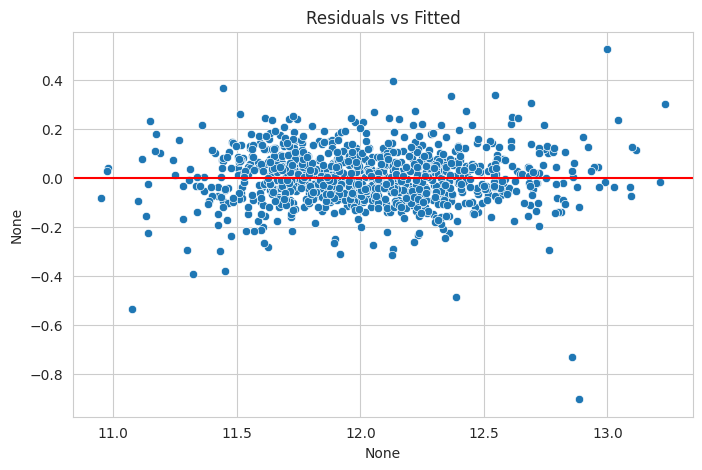

In [ ]:
y_pred = model.fittedvalues
residuals = model.resid

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.show()

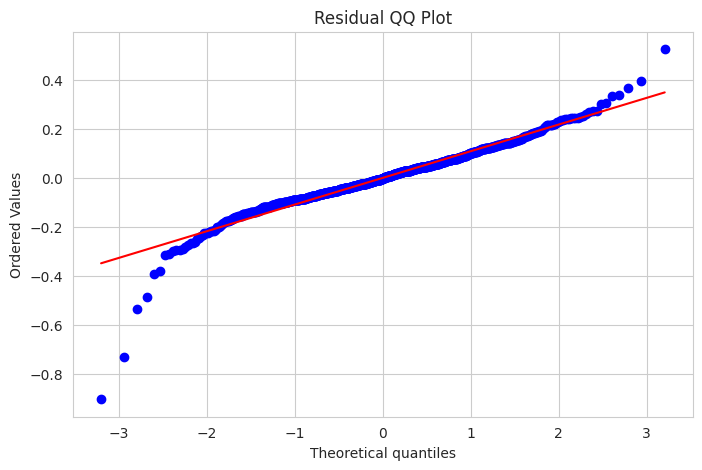

In [ ]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residual QQ Plot")
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, X_train_sm)

print("LM Stat:", bp_test[0])
print("p-value:", bp_test[1])

LM Stat: 527.3847728502454
p-value: 6.486370602507009e-43


In [ ]:
# Prepare validation
X_val_sm = sm.add_constant(X_val_vif)

# Predict
y_val_pred_log = model.predict(X_val_sm)

# 🔥 Force numeric (fix)
y_val_pred_log = pd.to_numeric(y_val_pred_log, errors='coerce')

# Convert back from log
import numpy as np
y_val_pred = np.exp(y_val_pred_log) - 1

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 27411.938286225897
R2: 0.8760145037598605


Time Series Connection

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Example (replace with your time series)
result = adfuller(y_train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -32.237097477425785
p-value: 0.0


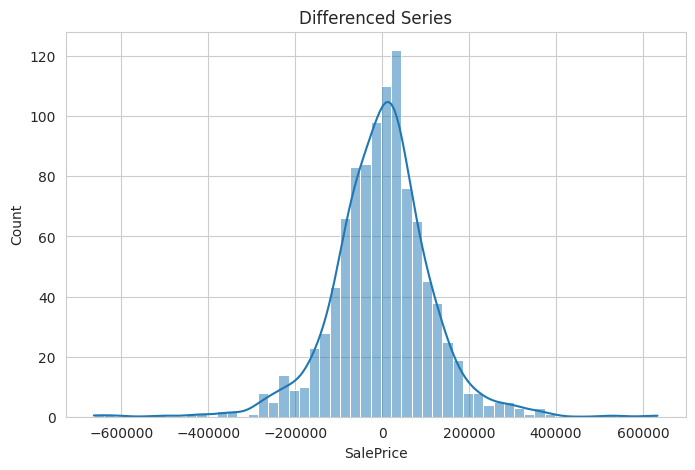

In [ ]:
y_diff = y_train.diff().dropna()

sns.histplot(y_diff, kde=True)
plt.title("Differenced Series")
plt.show()

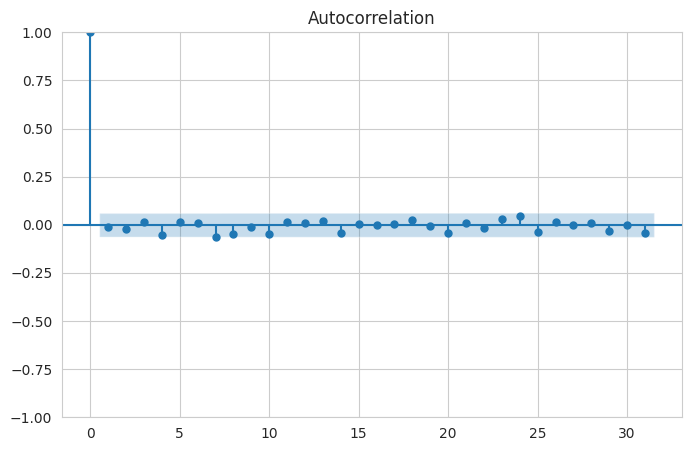

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(y_train)
plt.show()

LASSO REGRESSION


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_vif)
X_val_scaled   = scaler.transform(X_val_vif)

In [ ]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[0.1, 1, 10, 100], cv=5)
ridge.fit(X_train_scaled, y_train_log)

print("Best alpha:", ridge.alpha_)

Best alpha: 100.0


In [ ]:
y_val_pred_log_ridge = ridge.predict(X_val_scaled)
y_val_pred_ridge = np.exp(y_val_pred_log_ridge) - 1

In [ ]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train_log)

print("Best alpha:", lasso.alpha_)

Best alpha: 0.0021288536979461085


In [ ]:
y_val_pred_log_lasso = lasso.predict(X_val_scaled)
y_val_pred_lasso = np.exp(y_val_pred_log_lasso) - 1

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f}, R2: {r2:.4f}")

# OLS
evaluate(y_val, y_val_pred, "OLS")

# Ridge
evaluate(y_val, y_val_pred_ridge, "Ridge")

# Lasso
evaluate(y_val, y_val_pred_lasso, "Lasso")

OLS -> RMSE: 27411.94, R2: 0.8760
Ridge -> RMSE: 26527.48, R2: 0.8839
Lasso -> RMSE: 26283.32, R2: 0.8860


In [ ]:
coef = pd.Series(lasso.coef_, index=X_train_vif.columns)

selected_features = coef[coef != 0]

print("Selected features:", len(selected_features))
selected_features.head(10)

Selected features: 99


,0
Id,-0.005914
LotFrontage,-0.000229
LotArea,0.009140
OverallQual,0.100375
OverallCond,0.029493
YearRemodAdd,0.014960
TotalBsmtSF,0.026906
LowQualFinSF,0.000048
BsmtFullBath,0.021320
FullBath,0.032583


Evaluation + Interpretation

In [ ]:
# From statsmodels summary
print("R-squared:", model.rsquared)
print("Adjusted R-squared:", model.rsquared_adj)

R-squared: 0.9196938537216905
Adjusted R-squared: 0.9056472090331945


In [ ]:
# Prepare test
X_test_sm = sm.add_constant(X_test_vif)

# Predict
y_test_pred_log = model.predict(X_test_sm)

# 🔥 HARD FIX: force pure numpy float array
import numpy as np

y_test_pred_log = np.array(y_test_pred_log, dtype=float)

# Convert back
y_test_pred = np.exp(y_test_pred_log) - 1

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def safe_predict(model, X):
    X_sm = sm.add_constant(X)
    y_log = model.predict(X_sm)

    # 🔥 force clean numeric array
    y_log = np.asarray(y_log, dtype=float)

    # convert back from log
    y = np.exp(y_log) - 1
    return y

In [ ]:
# Validation predictions
y_val_pred = safe_predict(model, X_val_vif)

# Test predictions
y_test_pred = safe_predict(model, X_test_vif)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Validation
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)

# Test
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print("Validation RMSE:", rmse_val)
print("Validation R2:", r2_val)

print("Test RMSE:", rmse_test)
print("Test R2:", r2_test)

Validation RMSE: 27411.938286225897
Validation R2: 0.8760145037598605
Test RMSE: 29960.341382275314
Test R2: 0.8540452123545472


In [ ]:
print("R-squared:", model.rsquared)
print("Adjusted R-squared:", model.rsquared_adj)

R-squared: 0.9196938537216905
Adjusted R-squared: 0.9056472090331945


In [ ]:
print("F-statistic:", model.fvalue)
print("F-test p-value:", model.f_pvalue)

F-statistic: 65.47427333126082
F-test p-value: 0.0


In [ ]:
coef_table = model.summary2().tables[1]
coef_table.head()

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,20.456948,6.481807e+00,3.156056,1.654274e-03,7.735120e+00,33.178775
Id,-0.000018,9.628734e-06,-1.841505,6.588821e-02,-3.662966e-05,0.000001
LotFrontage,-0.000557,2.853584e-04,-1.951682,5.129687e-02,-1.117001e-03,0.000003
LotArea,0.000002,6.019868e-07,2.520598,1.189358e-02,3.358490e-07,0.000003
OverallQual,0.062754,5.982454e-03,10.489736,2.543533e-24,5.101262e-02,0.074496


In [ ]:
def clean_X(X):
    import pandas as pd
    import numpy as np

    X = X.copy()

    # force numeric
    X = X.apply(pd.to_numeric, errors='coerce')

    # remove NaNs created
    X = X.fillna(0)

    # force float
    X = X.astype(float)

    return X

In [ ]:
X_train_vif = clean_X(X_train_vif)
X_val_vif   = clean_X(X_val_vif)
X_test_vif  = clean_X(X_test_vif)

In [ ]:
X_train_sm = sm.add_constant(X_train_vif)

y_train_log = np.log1p(y_train)

model = sm.OLS(y_train_log, X_train_sm).fit()

In [ ]:
# Use test set
X_test_sm = sm.add_constant(X_test_vif)

pred = model.get_prediction(X_test_sm)
pred_summary = pred.summary_frame(alpha=0.05)

pred_summary[['mean', 'obs_ci_lower', 'obs_ci_upper']].head()

,mean,obs_ci_lower,obs_ci_upper
1424,11.740274,11.483730,11.996818
172,12.321084,12.057257,12.584911
874,11.499758,11.246789,11.752727
158,12.339272,12.088431,12.590114
528,11.530733,11.277010,11.784456
